# 🤖 Modelo “MargaritaLSG1”
#### IA para Traducción de Lengua de Señas Guatemalteca
#### Versión: 1.0
#### Autor: Fernando Josué Rivas Mauricio

## 1. Importaciones y utilidades

In [9]:
import os
import cv2
import math
import json
from datetime import datetime
import mediapipe as mp
from mediapipe.python.solutions.holistic import Holistic

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score
)

import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback
from tensorflow.keras.losses import CategoricalCrossentropy
import math
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint
from tensorflow.keras.losses import CategoricalCrossentropy
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

ROOT_PATH = "data"
FRAME_ACTIONS_PATH = "frases"  # carpeta por palabra/frase
FONT = cv2.FONT_HERSHEY_SIMPLEX
FONT_SIZE = 1
FONT_POS = (10, 30)

# Crear carpeta si no existe
def create_folder(path):
    if not os.path.exists(path):
        os.makedirs(path)

# Detectar si hay manos en los resultados
def there_hand(results):
    return results.left_hand_landmarks or results.right_hand_landmarks

# Dibujar los keypoints de las manos
def draw_keypoints(image, results):
    if results.left_hand_landmarks:
        mp.solutions.drawing_utils.draw_landmarks(image, results.left_hand_landmarks, mp.solutions.holistic.HAND_CONNECTIONS)
    if results.right_hand_landmarks:
        mp.solutions.drawing_utils.draw_landmarks(image, results.right_hand_landmarks, mp.solutions.holistic.HAND_CONNECTIONS)

# Aplicar MediaPipe
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = model.process(image)
    return results

# Extraer keypoints de ambas manos
def extract_keypoints(results):
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21 * 3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21 * 3)
    return np.concatenate([lh, rh])

## 2. Captura de muestras

In [17]:
def capture_samples_npy(path, margin_frame=1, min_cant_frames=30, delay_frames=3):
    """
    CAPTURA DE MUESTRAS PARA UNA PALABRA Y GUARDA KEYPOINTS COMO .NPY
    - Comienza a grabar cuando detecta mano.
    - Sigue 'delay_frames' tras dejar de ver la mano, para no cortar brusco.
    - Recorta 'margin_frame' al inicio y 'delay_frames' al final ANTES de guardar.
    """
    create_folder(path)

    registro_actual = len([f for f in os.listdir(path) if f.endswith(".npy")]) + 1

    cap = cv2.VideoCapture(1)  # 0 suele ser la cámara principal (cambia si usas 1)
    window_name = "Vista previa de señas"
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(window_name, 800, 600)

    DISPLAY_WIDTH, DISPLAY_HEIGHT = 800, 600

    recording = False
    sequence = []
    count_frame = 0
    fix_frames = 0  # cuenta frames desde que se perdió la mano

    try:
        with mp.solutions.holistic.Holistic(min_detection_confidence=0.5,
                                            min_tracking_confidence=0.5) as holistic_model:
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break

                image = frame.copy()
                results = mediapipe_detection(frame, holistic_model)
                hand_present = there_hand(results)

                if hand_present:
                    # Si volvimos a ver la mano, resetea el contador de "perdida"
                    fix_frames = 0

                    # Si no estaba grabando, inicia
                    if not recording:
                        recording = True
                        sequence = []
                        count_frame = 0

                    count_frame += 1

                    # Mostrar estado
                    cv2.putText(image, f'Registro {registro_actual}...', (10, 30), FONT, FONT_SIZE, (100, 200, 255), 2)
                    cv2.putText(image, 'Capturando...', (20, image.shape[0] - 20), FONT, FONT_SIZE, (0, 50, 255), 2)

                    # A partir del margen inicial, acumulamos keypoints
                    if count_frame > margin_frame:
                        keypoints = extract_keypoints(results)
                        if keypoints is not None:
                            sequence.append(keypoints)

                elif recording:
                    # Se perdió la mano pero seguimos unos frames por "delay"
                    fix_frames += 1
                    cv2.putText(image, f'Registro {registro_actual}...', (10, 30), FONT, FONT_SIZE, (100, 200, 255), 2)
                    cv2.putText(image, f'Finalizando... ({fix_frames}/{delay_frames})', (20, image.shape[0] - 20),
                                FONT, FONT_SIZE, (0, 165, 255), 2)

                    if fix_frames >= delay_frames:
                        # Recorte final: quitamos 'delay_frames' al final y 'margin_frame' (ya no agregamos durante margen, pero por seguridad)
                        if delay_frames > 0 and len(sequence) > delay_frames:
                            sequence = sequence[:-delay_frames]

                        # Validar longitud mínima
                        if len(sequence) >= min_cant_frames:
                            timestamp = datetime.now().strftime('%y%m%d%H%M%S%f')
                            npy_path = os.path.join(path, f'sample_{timestamp}.npy')
                            np.save(npy_path, np.array(sequence))
                            print(f"✅ Muestra guardada: {npy_path}")
                            registro_actual += 1
                        else:
                            print("⚠️ Muestra descartada por ser muy corta.")

                        # Reset total
                        recording = False
                        sequence = []
                        count_frame = 0
                        fix_frames = 0

                else:
                    # No se está grabando y no hay mano: estado en espera
                    cv2.putText(image, f'Registro {registro_actual}...', (10, 30), FONT, FONT_SIZE, (100, 200, 255), 2)
                    cv2.putText(image, 'Listo para capturar...', (20, image.shape[0] - 20),
                                FONT, FONT_SIZE, (0, 220, 100), 2)

                # Dibujo y display
                draw_keypoints(image, results)
                image_display = cv2.resize(image, (DISPLAY_WIDTH, DISPLAY_HEIGHT))
                cv2.imshow(window_name, image_display)

                # Salir
                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break
    finally:
        cap.release()
        cv2.destroyAllWindows()

if __name__ == "__main__":
    palabra = "gracias"
    word_path = os.path.join(ROOT_PATH, FRAME_ACTIONS_PATH, palabra)
    capture_samples_npy(word_path)

✅ Muestra guardada: data\frases\gracias\sample_250911182531253620.npy
⚠️ Muestra descartada por ser muy corta.
⚠️ Muestra descartada por ser muy corta.
⚠️ Muestra descartada por ser muy corta.
⚠️ Muestra descartada por ser muy corta.
⚠️ Muestra descartada por ser muy corta.
⚠️ Muestra descartada por ser muy corta.
✅ Muestra guardada: data\frases\gracias\sample_250911182551699380.npy
✅ Muestra guardada: data\frases\gracias\sample_250911182557178399.npy
⚠️ Muestra descartada por ser muy corta.
⚠️ Muestra descartada por ser muy corta.
⚠️ Muestra descartada por ser muy corta.
⚠️ Muestra descartada por ser muy corta.
✅ Muestra guardada: data\frases\gracias\sample_250911182609652599.npy
✅ Muestra guardada: data\frases\gracias\sample_250911182614874931.npy
✅ Muestra guardada: data\frases\gracias\sample_250911182619535981.npy
✅ Muestra guardada: data\frases\gracias\sample_250911182624444462.npy
✅ Muestra guardada: data\frases\gracias\sample_250911182629309559.npy
✅ Muestra guardada: data\frase

## 3. Normalización

In [18]:
ROOT_PATH = "data"
FRAME_ACTIONS_PATH = "frases"
MODEL_FRAMES = 30  

def normalize_keypoints_sequence(sequence, target_len=30):
    current_len = len(sequence)
    if current_len == target_len:
        return sequence
    elif current_len > target_len:
        # Reducir seleccionando frames uniformemente
        step = current_len / target_len
        indices = np.arange(0, current_len, step).astype(int)[:target_len]
        return sequence[indices]
    else:
        # Interpolar si es menor
        indices = np.linspace(0, current_len - 1, target_len)
        interpolated = []
        for i in indices:
            lower = int(np.floor(i))
            upper = int(np.ceil(i))
            weight = i - lower
            if upper >= current_len:
                upper = current_len - 1
            interpolated_frame = (1 - weight) * sequence[lower] + weight * sequence[upper]
            interpolated.append(interpolated_frame)
        return np.array(interpolated)

def process_npy_directory(word_directory, target_len=30):
    for fname in os.listdir(word_directory):
        if fname.endswith(".npy"):
            full_path = os.path.join(word_directory, fname)
            sequence = np.load(full_path)
            normalized = normalize_keypoints_sequence(sequence, target_len)
            np.save(full_path, normalized)
            print(f"✅ Normalizado: {fname} → {normalized.shape}")

if __name__ == "__main__":
    word_ids = [w for w in os.listdir(os.path.join(ROOT_PATH, FRAME_ACTIONS_PATH))]

    for word_id in word_ids:
        word_path = os.path.join(ROOT_PATH, FRAME_ACTIONS_PATH, word_id)
        if os.path.isdir(word_path):
            print(f"\n📦 Normalizando muestras de: {word_id}")
            process_npy_directory(word_path, target_len=MODEL_FRAMES)


📦 Normalizando muestras de: adios
✅ Normalizado: sample_250911173514093009.npy → (30, 126)
✅ Normalizado: sample_250911173518505603.npy → (30, 126)
✅ Normalizado: sample_250911173522246092.npy → (30, 126)
✅ Normalizado: sample_250911173526969190.npy → (30, 126)
✅ Normalizado: sample_250911173531286471.npy → (30, 126)
✅ Normalizado: sample_250911173535634534.npy → (30, 126)
✅ Normalizado: sample_250911173540405201.npy → (30, 126)
✅ Normalizado: sample_250911173544863093.npy → (30, 126)
✅ Normalizado: sample_250911173549505823.npy → (30, 126)
✅ Normalizado: sample_250911173555224834.npy → (30, 126)
✅ Normalizado: sample_250911173559660009.npy → (30, 126)
✅ Normalizado: sample_250911173603810097.npy → (30, 126)
✅ Normalizado: sample_250911173607785777.npy → (30, 126)
✅ Normalizado: sample_250911173611721971.npy → (30, 126)
✅ Normalizado: sample_250911173615495941.npy → (30, 126)
✅ Normalizado: sample_250911173619508317.npy → (30, 126)
✅ Normalizado: sample_250911173623721692.npy → (30, 1

## 4. Entrenamiento

In [10]:

MODEL_NAME = "MargaritaLSG1"
MODEL_PATH = os.path.join("models", f"{MODEL_NAME}.h5")

# Rutas relacionadas (manteniendo consistencia)
BASE_DIR    = os.path.dirname(MODEL_PATH)
BEST_VAL_H5 = os.path.join(BASE_DIR, f"best_val_loss_{MODEL_NAME}.h5")
BEST_F1_H5  = os.path.join(BASE_DIR, f"best_macro_f1_{MODEL_NAME}.h5")
LABELS_JSON = os.path.join(BASE_DIR, f"labels_{MODEL_NAME}.json")
CM_PNG      = os.path.join(BASE_DIR, f"confusion_matrix_{MODEL_NAME}.png")

LENGTH_KEYPOINTS = 126      # SOLO manos (21*3*2)
MODEL_FRAMES = 30           # frames por secuencia (coincidir con inferencia)

def load_dataset(base_path="data/frases"):
    X = []
    y = []
    label_map = {}

    palabras = sorted(os.listdir(base_path))
    for idx, palabra in enumerate(palabras):
        label_map[palabra] = idx
        palabra_path = os.path.join(base_path, palabra)
        for archivo in os.listdir(palabra_path):
            if archivo.endswith(".npy"):
                secuencia = np.load(os.path.join(palabra_path, archivo))
                if secuencia.shape[0] == MODEL_FRAMES:
                    X.append(secuencia)
                    y.append(idx)

    X = np.array(X)
    y = to_categorical(np.array(y))
    return X, y, label_map

In [11]:
def get_model(max_length_frames, output_length: int):
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=(max_length_frames, LENGTH_KEYPOINTS), kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.5))
    model.add(LSTM(128, return_sequences=False, kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dense(output_length, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

✅ Cargado: N=5600 | Clases=14 -> ['adios', 'cantar', 'cual', 'desconectar', 'dolor', 'donde', 'estudiar', 'feliz', 'gracias', 'hola', 'jugar', 'por_que', 'reir', 'ser']
✅ Total muestras: 5600, Clases: 14
MODEL in/out (entrenamiento): (None, 30, 126) -> (None, 14)
⚖️  Class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0, 8: 1.0, 9: 1.0, 10: 1.0, 11: 1.0, 12: 1.0, 13: 1.0}
Epoch 1/150
559/560 [============================>.] - ETA: 0s - loss: 1.6046 - accuracy: 0.4528
Epoch 1: val_loss improved from inf to 0.86195, saving model to C:\Code\ManosQueHablan\ia-python\notebook\Modelo No. 2\models\best_val_loss_MargaritaLSG1.h5

💾 Macro-F1 mejoró a 0.7745. Guardado: C:\Code\ManosQueHablan\ia-python\notebook\Modelo No. 2\models\best_macro_f1_MargaritaLSG1.h5
560/560 [==============================] - 37s 46ms/step - loss: 1.6030 - accuracy: 0.4533 - val_loss: 0.8619 - val_accuracy: 0.7830 - val_macro_f1: 0.7745 - lr: 3.0000e-04
Epoch 2/150
559/560 [====================

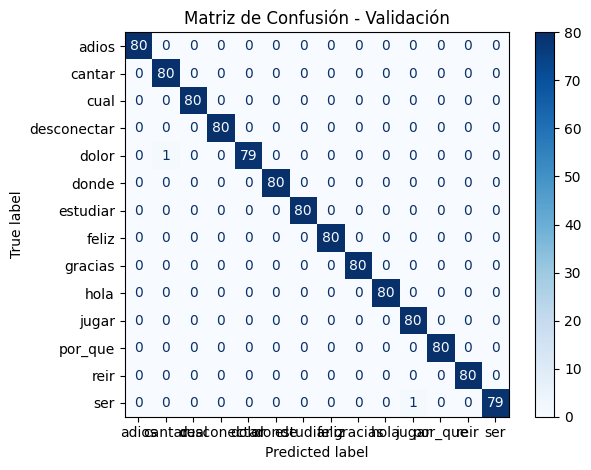

In [16]:

# ======================================================
# Config global
# ======================================================
SEED = 42
MODEL_FRAMES = 30
LENGTH_KEYPOINTS = 126  # (ej: 63 jp * 2 coords) + rest
LR_INIT = 3e-4

BASE_DIR = os.path.abspath(os.path.dirname(__file__)) if "__file__" in globals() else os.getcwd()
OUT_DIR  = os.path.join(BASE_DIR, "models")
FIG_DIR  = os.path.join(BASE_DIR, "figs")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

BEST_VAL_H5 = os.path.join(OUT_DIR, "best_val_loss_MargaritaLSG1.h5")
BEST_F1_H5  = os.path.join(OUT_DIR, "best_macro_f1_MargaritaLSG1.h5")
MODEL_PATH  = os.path.join(OUT_DIR, "action_final_best_val.h5")
LABELS_JSON = os.path.join(OUT_DIR, "labels.json")
CM_PNG      = os.path.join(FIG_DIR,  "cm_validacion.png")

# ======================================================
# Semillas (reproducibilidad)
# ======================================================
def set_global_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_global_seed(SEED)

# ======================================================
# Stubs a reemplazar por tus funciones reales
# ======================================================
def get_model(input_length: int, output_length: int) -> tf.keras.Model:
    """
    Reemplaza esta función por tu arquitectura real.
    Debe recibir (MODEL_FRAMES, LENGTH_KEYPOINTS) y devolver C clases.
    """
    inp = tf.keras.Input(shape=(input_length, LENGTH_KEYPOINTS))
    x = tf.keras.layers.Masking(mask_value=-0.2)(inp)  # compatible con token de ausencia
    x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True))(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128))(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    out = tf.keras.layers.Dense(output_length, activation="softmax")(x)
    model = tf.keras.Model(inp, out)
    return model

def load_dataset() -> Tuple[np.ndarray, np.ndarray, Dict[int, str]]:
    """
    Espera:
      BASE_DIR/data/frases/
        adios/*.npy
        cantar/*.npy
        hola/*.npy
        ...
    Cada .npy = (T, LENGTH_KEYPOINTS). Si T != MODEL_FRAMES, se reescala temporalmente.
    """
    data_root = os.path.join(BASE_DIR, "data", "frases")
    assert os.path.isdir(data_root), f"No existe carpeta: {data_root}"

    # Clases por nombre de carpeta (orden alfabético para mapping estable)
    class_names = sorted([d for d in os.listdir(data_root)
                          if os.path.isdir(os.path.join(data_root, d))])
    assert len(class_names) > 0, "No hay carpetas de clases en data/frases"

    def _resample_time(seq: np.ndarray, T_out: int) -> np.ndarray:
        # seq: (T_in, K) -> (T_out, K)
        T_in = seq.shape[0]
        if T_in == T_out:
            return seq
        idx = np.linspace(0, T_in - 1, T_out)
        lo = np.floor(idx).astype(int)
        hi = np.clip(lo + 1, 0, T_in - 1)
        a = idx - lo
        return (seq[lo] * (1 - a)[:, None] + seq[hi] * a[:, None]).astype(seq.dtype)

    X_list, y_list = [], []
    for ci, cname in enumerate(class_names):
        cdir = os.path.join(data_root, cname)
        files = [f for f in os.listdir(cdir) if f.lower().endswith(".npy")]
        if not files:
            print(f"⚠️  Sin .npy en {cdir}, se omite.")
            continue
        for f in files:
            arr = np.load(os.path.join(cdir, f))
            # Asegurar 2D (T, K)
            if arr.ndim == 3:
                # si vino (T, J, 2) -> aplana a (T, J*2)
                T, J, D = arr.shape
                arr = arr.reshape(T, J * D)
            if arr.ndim != 2:
                print(f"⚠️  Forma no válida {arr.shape} en {f}, se omite.")
                continue
            # Chequear K
            if arr.shape[1] != LENGTH_KEYPOINTS:
                print(f"⚠️  K={arr.shape[1]} != {LENGTH_KEYPOINTS} en {f}, se omite.")
                continue
            # Reescalar T a MODEL_FRAMES si hace falta
            arr = _resample_time(arr, MODEL_FRAMES)
            X_list.append(arr.astype(np.float32))
            y_list.append(ci)

    assert len(X_list) > 0, "No se cargaron muestras. Revisa las formas de los .npy."

    X = np.stack(X_list, axis=0)                              # (N, MODEL_FRAMES, LENGTH_KEYPOINTS)
    y_idx = np.array(y_list, dtype=np.int64)                  # (N,)
    C = len(class_names)
    y_onehot = np.eye(C, dtype=np.float32)[y_idx]            # (N, C)

    # label_map: idx -> nombre
    label_map = {i: class_names[i] for i in range(C)}

    print(f"✅ Cargado: N={X.shape[0]} | Clases={C} -> {class_names}")
    return X, y_onehot, label_map

# ======================================================
# Aumentos para keypoints (solo en train)
# ======================================================
def _reshape_xy(seq: np.ndarray):
    """Divide en XY (T, J, 2) y resto (visibilidad/flags) plano."""
    T, K = seq.shape
    n_xy = (K // 2) * 2
    xy = seq[:, :n_xy].reshape(T, n_xy // 2, 2)  # (T, J, 2)
    rest = seq[:, n_xy:]
    return xy, rest, n_xy

def aug_jitter(seq, sigma=0.01):
    xy, rest, n_xy = _reshape_xy(seq)
    noise = np.random.normal(0, sigma, xy.shape)
    xy_aug = np.clip(xy + noise, 0.0, 1.0)
    return np.concatenate([xy_aug.reshape(seq.shape[0], n_xy), rest], axis=1)

def aug_scale_translate(seq, scale_range=(0.96, 1.04), trans_range=(-0.015, 0.015)):
    xy, rest, n_xy = _reshape_xy(seq)
    s  = np.random.uniform(*scale_range)
    tx = np.random.uniform(*trans_range)
    ty = np.random.uniform(*trans_range)
    center = np.array([0.5, 0.5])
    xy_aug = (xy - center) * s + center
    xy_aug[..., 0] = np.clip(xy_aug[..., 0] + tx, 0.0, 1.0)
    xy_aug[..., 1] = np.clip(xy_aug[..., 1] + ty, 0.0, 1.0)
    return np.concatenate([xy_aug.reshape(seq.shape[0], n_xy), rest], axis=1)

def aug_rotate(seq, deg=5):
    rad = np.deg2rad(np.random.uniform(-deg, deg))
    c, s = math.cos(rad), math.sin(rad)
    R = np.array([[c, -s], [s, c]])
    xy, rest, n_xy = _reshape_xy(seq)
    center = np.array([0.5, 0.5])
    xy_c = xy - center
    xy_r = np.einsum('ab,tkb->tka', R, xy_c)
    xy_aug = np.clip(xy_r + center, 0.0, 1.0)
    return np.concatenate([xy_aug.reshape(seq.shape[0], n_xy), rest], axis=1)

def aug_time_warp(seq, strength=0.05):
    """Warp temporal suave. (Puede no ser estrictamente monótono; suficiente en práctica)."""
    T = seq.shape[0]
    t = np.linspace(0, 1, T)
    warp = t + strength * np.sin(2 * np.pi * t * np.random.uniform(0.8, 1.2))
    warp = np.clip(warp, 0, 1)
    new_idx = warp * (T - 1)
    lo = np.floor(new_idx).astype(int)
    hi = np.clip(lo + 1, 0, T - 1)
    alpha = new_idx - lo
    out = seq[lo] * (1 - alpha[:, None]) + seq[hi] * alpha[:, None]
    return out.astype(seq.dtype)

def aug_frame_dropout_xy(seq, max_drop=2):
    """Elimina frames y reinterpola SOLO XY. 'rest' queda intacto."""
    xy, rest, n_xy = _reshape_xy(seq)
    T = xy.shape[0]
    d = np.random.randint(0, max_drop + 1)
    if d == 0:
        return seq
    keep_idx = sorted(np.random.choice(np.arange(T), T - d, replace=False))
    kept_xy = xy[keep_idx]
    new_idx = np.linspace(0, kept_xy.shape[0]-1, T)
    lo = np.floor(new_idx).astype(int)
    hi = np.clip(lo + 1, 0, kept_xy.shape[0]-1)
    alpha = new_idx - lo
    out_xy = kept_xy[lo] * (1 - alpha[:, None, None]) + kept_xy[hi] * alpha[:, None, None]
    out = np.concatenate([out_xy.reshape(T, n_xy), rest], axis=1)
    return out.astype(seq.dtype)

def aug_keypoint_mask(seq, max_points=3, missing_token=-0.2):
    """Enmascara J keypoints con un token fuera de [0,1] para distinguir ausencia real de 'borde'."""
    xy, rest, n_xy = _reshape_xy(seq)
    J = xy.shape[1]
    m = np.random.randint(0, max_points + 1)
    if m == 0:
        return np.concatenate([xy.reshape(seq.shape[0], n_xy), rest], axis=1)
    idx = np.random.choice(np.arange(J), m, replace=False)
    xy_mask = xy.copy()
    xy_mask[:, idx, :] = missing_token
    return np.concatenate([xy_mask.reshape(seq.shape[0], n_xy), rest], axis=1)

def augment_sequence(seq: np.ndarray):
    if np.random.rand() < 0.8: seq = aug_jitter(seq, 0.01)
    if np.random.rand() < 0.5: seq = aug_scale_translate(seq, (0.96, 1.04), (-0.015, 0.015))
    if np.random.rand() < 0.3: seq = aug_rotate(seq, 5)
    if np.random.rand() < 0.4: seq = aug_time_warp(seq, 0.05)
    if np.random.rand() < 0.3: seq = aug_frame_dropout_xy(seq, 2)
    if np.random.rand() < 0.2: seq = aug_keypoint_mask(seq, 3, missing_token=-0.2)
    return seq

# ======================================================
# tf.data (batch-wise augment rápido)
# ======================================================
def make_tf_dataset(X, y, batch_size=8, training=True, seed=SEED):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(min(10000, len(X)), reshuffle_each_iteration=True, seed=seed)
    ds = ds.batch(batch_size, drop_remainder=False)

    if training:
        def _batch_aug(x, y):
            x = tf.numpy_function(
                func=lambda arr: np.stack([augment_sequence(a) for a in arr], axis=0).astype(np.float32),
                inp=[x],
                Tout=tf.float32
            )
            x.set_shape((None, X.shape[1], X.shape[2]))
            return x, y
        ds = ds.map(_batch_aug, num_parallel_calls=tf.data.AUTOTUNE)

    return ds.prefetch(tf.data.AUTOTUNE)

# ======================================================
# Pesos por clase
# ======================================================
def compute_class_weights(y_onehot: np.ndarray):
    counts = y_onehot.sum(axis=0)
    total = counts.sum()
    weights = total / (len(counts) * np.maximum(counts, 1))
    return {i: float(w) for i, w in enumerate(weights)}

# ======================================================
# Callback Macro-F1 (loggea y checkpoint opcional)
# ======================================================
class MacroF1Callback(Callback):
    def __init__(self, X_val, y_val, save_path=None):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.best = -1.0
        self.save_path = save_path

    def on_epoch_end(self, epoch, logs=None):
        y_prob = self.model.predict(self.X_val, verbose=0)
        y_pred = y_prob.argmax(axis=1)
        y_true = self.y_val.argmax(axis=1)
        macro_f1 = f1_score(y_true, y_pred, average="macro")
        if logs is not None:
            logs["val_macro_f1"] = macro_f1
        if macro_f1 > self.best:
            self.best = macro_f1
            if self.save_path:
                self.model.save(self.save_path)
                print(f"\n💾 Macro-F1 mejoró a {macro_f1:.4f}. Guardado: {self.save_path}")

# ======================================================
# Entrenamiento principal
# ======================================================
def train_model_from_npy(epochs=150, batch_size=8, use_class_weights=True):
    # 1) Cargar dataset
    X, y, label_map = load_dataset()  # y one-hot (N, C)
    print(f"✅ Total muestras: {X.shape[0]}, Clases: {len(label_map)}")

    assert X.ndim == 3 and X.shape[1] == MODEL_FRAMES and X.shape[2] == LENGTH_KEYPOINTS, \
        f"X shape {X.shape} debe ser (N, {MODEL_FRAMES}, {LENGTH_KEYPOINTS})"
    assert y.ndim == 2, f"y debe ser one-hot (N, C); shape actual: {y.shape}"

    X = X.astype(np.float32)

    # 2) Split (estratificado). TIP: si tienes id_persona o id_video usa GroupShuffleSplit.
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=np.argmax(y, axis=1)
    )

    # 3) Modelo
    model = get_model(MODEL_FRAMES, output_length=y.shape[1])
    print("MODEL in/out (entrenamiento):", model.input_shape, "->", model.output_shape)

    # 4) Callbacks
    ckpt_val = ModelCheckpoint(
        filepath=BEST_VAL_H5, monitor="val_loss",
        save_best_only=True, save_weights_only=False, verbose=1
    )
    ckpt_f1  = MacroF1Callback(X_val, y_val, save_path=BEST_F1_H5)

    early_stop = EarlyStopping(
        monitor="val_macro_f1", mode="max", patience=10,
        restore_best_weights=True, verbose=1
    )
    rlrop = ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5,
        min_lr=1e-6, verbose=1
    )

    # 5) Loss con label smoothing (mejor calibración)
    loss = CategoricalCrossentropy(label_smoothing=0.05)

    # 6) Datasets TF
    train_ds = make_tf_dataset(X_train, y_train, batch_size=batch_size, training=True,  seed=SEED)
    val_ds   = make_tf_dataset(X_val,   y_val,   batch_size=batch_size, training=False, seed=SEED)

    # 7) Class weights (opcional)
    class_weights = compute_class_weights(y_train) if use_class_weights else None
    if class_weights:
        print("⚖️  Class weights:", class_weights)

    # 8) Compilar y entrenar
    optimizer = tf.keras.optimizers.Adam(learning_rate=LR_INIT, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[ckpt_val, ckpt_f1, rlrop, early_stop],
        class_weight=class_weights,
        verbose=1
    )

    # 9) Guardar modelo final (pesos restaurados del mejor val_macro_f1 vía EarlyStopping)
    model.save(MODEL_PATH)
    print(f"💾 Modelo final guardado en: {MODEL_PATH}")

    # 10) Guardar labels
    with open(LABELS_JSON, "w", encoding="utf-8") as f:
        json.dump(label_map, f, ensure_ascii=False, indent=2)
    print(f"🏷️  Labels guardadas en: {LABELS_JSON}")

    # 11) Matriz de confusión y reporte (validación pura)
    y_pred = model.predict(X_val, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_val, axis=1)

    # Orden de etiquetas fijo 0..C-1
    idx_to_name = [label_map[i] for i in range(len(label_map))]
    cm = confusion_matrix(y_true, y_pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=idx_to_name)
    disp.plot(cmap="Blues", values_format=".0f")
    plt.title("Matriz de Confusión - Validación")
    plt.tight_layout()
    plt.savefig(CM_PNG, dpi=160)
    print(f"🖼️  Matriz de confusión guardada en: {CM_PNG}")
    # plt.show()  # descomenta si entrenas local con UI

    train_acc = history.history.get('accuracy', [0])[-1]
    val_acc   = history.history.get('val_accuracy', [0])[-1]
    print(f"\n📊 Accuracy final - Train: {train_acc:.2f} | Val: {val_acc:.2f}")
    if abs(train_acc - val_acc) > 0.2:
        print("⚠️ Posible overfitting")
    elif max(history.history.get('val_accuracy', [0])) < 0.6:
        print("⚠️ Posible underfitting")
    else:
        print("✅ Buen desempeño general")

    print("\n📃 Classification report (validación):")
    print(classification_report(y_true, y_pred_labels, target_names=idx_to_name))

    return model, label_map

# ============================
# Ejecución
# ============================
if __name__ == "__main__":
    # Ajusta epochs/batch según tu GPU
    model, label_map = train_model_from_npy(epochs=150, batch_size=8, use_class_weights=True)


## 5. Validaciones

In [23]:
MODEL_PATH = "models/MargaritaLSG1.h5"
DATA_PATH = "data/frases"
WORDS = sorted(os.listdir(DATA_PATH))  # nombres de las clases
MODEL_FRAMES = 30
MIN_LENGTH_FRAMES = 10
FONT = cv2.FONT_HERSHEY_SIMPLEX
FONT_POS = (10, 30)
FONT_SIZE = 1

def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    return model.process(image)

def there_hand(results):
    return results.left_hand_landmarks or results.right_hand_landmarks

def extract_keypoints(results):
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]) if results.left_hand_landmarks else np.zeros((21, 3))
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]) if results.right_hand_landmarks else np.zeros((21, 3))
    return np.concatenate([lh, rh]).flatten()

def normalize_keypoints(keypoints, target_length=30):
    current_length = len(keypoints)
    if current_length == target_length:
        return keypoints
    elif current_length > target_length:
        step = current_length / target_length
        indices = np.arange(0, current_length, step).astype(int)[:target_length]
        return [keypoints[i] for i in indices]
    else:
        indices = np.linspace(0, current_length - 1, target_length)
        interpolated = []
        for i in indices:
            lower = int(np.floor(i))
            upper = int(np.ceil(i))
            weight = i - lower
            if lower == upper:
                interpolated.append(keypoints[lower])
            else:
                interpolated.append(((1 - weight) * np.array(keypoints[lower]) + weight * np.array(keypoints[upper])).tolist())
        return interpolated

def draw_keypoints(image, results):
    mp_drawing = mp.solutions.drawing_utils
    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp.solutions.holistic.HAND_CONNECTIONS)
    if results.right_hand_landmarks:
        mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp.solutions.holistic.HAND_CONNECTIONS)

In [24]:
def evaluate_model(threshold=0.8, margin_frame=1, delay_frames=3, src=0):
    print("🟡 Cargando modelo...")
    model = load_model(MODEL_PATH)

    print("📷 Inicializando cámara...")
    cap = cv2.VideoCapture(src)
    if not cap.isOpened():
        print("❌ No se pudo abrir la cámara.")
        return

    sentence = []
    pred_label = ""
    pred_prob = 0.0
    kp_seq, count_frame, fix_frames = [], 0, 0
    recording = False

    with Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
        print("🎥 Traductor en vivo iniciado. Presiona 'q' para salir.")
        while True:
            ret, frame = cap.read()
            if not ret:
                print("⚠️ No se pudo leer el frame de la cámara.")
                break

            results = mediapipe_detection(frame, holistic)

            if there_hand(results) or recording:
                recording = False
                count_frame += 1
                if count_frame > margin_frame:
                    kp_frame = extract_keypoints(results)
                    kp_seq.append(kp_frame)
            else:
                if count_frame >= MIN_LENGTH_FRAMES + margin_frame:
                    fix_frames += 1
                    if fix_frames < delay_frames:
                        recording = True
                        continue

                    kp_seq = kp_seq[: -(margin_frame + delay_frames)]
                    kp_normalized = normalize_keypoints(kp_seq, target_length=MODEL_FRAMES)
                    input_data = np.expand_dims(np.array(kp_normalized), axis=0)

                    prediction = model.predict(input_data, verbose=0)[0]
                    max_idx = np.argmax(prediction)
                    max_prob = prediction[max_idx]

                    if max_prob > threshold:
                        pred_label = WORDS[max_idx]
                        pred_prob = max_prob * 100
                        sentence.insert(0, pred_label)

                kp_seq = []
                count_frame = 0
                fix_frames = 0
                recording = False

            # Mostrar texto y porcentaje en ventana
            cv2.rectangle(frame, (0, 0), (640, 60), (245, 117, 16), -1)
            cv2.putText(frame, f'{pred_label.upper()} ({pred_prob:.1f}%)', FONT_POS, FONT, FONT_SIZE, (255, 255, 255), 2)

            draw_keypoints(frame, results)
            cv2.imshow('Traductor LSP', frame)

            if cv2.waitKey(10) & 0xFF == ord('q'):
                print("🛑 Cerrando traductor.")
                break

        cap.release()
        cv2.destroyAllWindows()

if __name__ == "__main__":
    evaluate_model()

🟡 Cargando modelo...
📷 Inicializando cámara...
🎥 Traductor en vivo iniciado. Presiona 'q' para salir.
🛑 Cerrando traductor.


In [30]:
from contextlib import contextmanager
def evaluate_video(
    video_path: str,
    threshold: float = 0.8,
    margin_frame: int = 1,
    delay_frames: int = 3,
    output: bool = True,
    show_window: bool = False,
):
    """
    Evalúa un video en archivo en lugar de la cámara.
    - Detecta ventanas de gesto (aparece mano -> desaparece) y predice con el modelo.
    - Genera un MP4 anotado con el texto (si output=True).
    - Devuelve una lista de detecciones con tiempos de inicio/fin y probabilidad.
    """
    if not os.path.isfile(video_path):
        print(f"❌ No existe el archivo: {video_path}")
        return []

    print("🟡 Cargando modelo...")
    model = load_model(MODEL_PATH)

    print(f"🎬 Abriendo video: {video_path}")
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("❌ No se pudo abrir el video.")
        return []

    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)  or 640)
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 480)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)

    # Preparar salida de video
    writer = None
    out_path = None
    if output:
        base = os.path.splitext(os.path.basename(video_path))[0]
        out_path = f"resultado_{base}.mp4"
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(out_path, fourcc, fps, (width, height))

    detections = []  # cada item: {label, prob, start_frame, end_frame, start_time, end_time}

    kp_seq, count_frame, fix_frames = [], 0, 0
    recording = False

    pred_label = ""
    pred_prob = 0.0
    overlay_cooldown = 0  # frames para mostrar el texto en el video

    # --- MediaPipe Holistic context manager (usa tu helper si lo tienes) ---
    import mediapipe as mp
    with mp.solutions.holistic.Holistic(
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as holistic:

        frame_idx = 0
        print("▶️ Procesando frames...")
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            # Detección con tu helper (si ya lo tienes). Si no, usa el pipeline normal de MP:
            # results = mediapipe_detection(frame, holistic)
            # Si tu mediapipe_detection ya convierte a RGB y llama holistic.process, úsalo.
            # Aquí uso el helper por compatibilidad con tu notebook:
            results = mediapipe_detection(frame, holistic)

            if there_hand(results) or recording:
                recording = False
                count_frame += 1
                if count_frame > margin_frame:
                    kp_frame = extract_keypoints(results)  # Debe regresar vector de 126 (o lo que uses)
                    kp_seq.append(kp_frame)
            else:
                # Sección de cierre del gesto
                if count_frame >= MIN_LENGTH_FRAMES + margin_frame:
                    fix_frames += 1
                    if fix_frames < delay_frames:
                        recording = True
                        # seguimos acumulando el "colchón" de cierre
                    else:
                        # recorta margen + delay
                        if margin_frame + delay_frames > 0:
                            kp_seq = kp_seq[:-(margin_frame + delay_frames)] if len(kp_seq) > (margin_frame + delay_frames) else kp_seq

                        # normaliza y remuestrea a MODEL_FRAMES
                        kp_normalized = normalize_keypoints(kp_seq, target_length=MODEL_FRAMES)  # (30, D)
                        input_data = np.expand_dims(np.array(kp_normalized), axis=0)            # (1,30,D)

                        prediction = model.predict(input_data, verbose=0)[0]
                        max_idx = int(np.argmax(prediction))
                        max_prob = float(prediction[max_idx])

                        if max_prob > threshold:
                            pred_label = WORDS[max_idx]
                            pred_prob = max_prob * 100.0
                            overlay_cooldown = int(fps * 0.7)  # muestra ~0.7s el texto

                            # marca temporal (aprox): usamos frame actual como fin, y restamos la duración de la ventana
                            end_frame = frame_idx
                            dur_frames = len(kp_seq)
                            start_frame = max(0, end_frame - dur_frames)
                            detections.append({
                                "label": pred_label,
                                "prob": pred_prob,
                                "start_frame": start_frame,
                                "end_frame": end_frame,
                                "start_time": start_frame / fps,
                                "end_time": end_frame / fps,
                            })

                        # reset para siguiente gesto
                        kp_seq, count_frame, fix_frames, recording = [], 0, 0, False
                else:
                    # No hubo suficiente material para formar gesto
                    kp_seq, count_frame, fix_frames, recording = [], 0, 0, False

            # --- Overlay de texto (si hubo predicción reciente) ---
            if overlay_cooldown > 0:
                cv2.rectangle(frame, (0, 0), (max(300, width // 2), 60), (245, 117, 16), -1)
                cv2.putText(frame, f'{pred_label.upper()} ({pred_prob:.1f}%)',
                            (20, 40), FONT, FONT_SIZE, (255, 255, 255), 2)
                overlay_cooldown -= 1

            # Dibuja keypoints si quieres mantener tu visualización
            try:
                draw_keypoints(frame, results)
            except Exception:
                pass  # por si tu helper no está cargado aquí

            # Escribir/frame y/o mostrar
            if writer is not None:
                writer.write(frame)

            if show_window:
                cv2.imshow('Traductor LSP (video)', frame)
                if cv2.waitKey(1) & 0xFF == ord('q'):
                    break

            frame_idx += 1

    cap.release()
    if writer is not None:
        writer.release()
    if show_window:
        cv2.destroyAllWindows()

    # --- Resumen ---
    print("✅ Detecciones:")
    if not detections:
        print("   (sin resultados sobre el umbral)")
    else:
        for i, d in enumerate(detections, 1):
            print(f" {i:02d}. {d['label']}  {d['prob']:.1f}%  "
                  f"{d['start_time']:.2f}s → {d['end_time']:.2f}s  "
                  f"(frames {d['start_frame']}–{d['end_frame']})")

    if out_path:
        print(f"💾 Video anotado: {out_path}")

    return detections

In [31]:
detecciones = evaluate_video(
    "prueba.mp4",   # ruta a tu video
    threshold=0.8,   # probabilidad mínima aceptada
    output=True,     # genera un video anotado
    show_window=False # pon True si quieres que se abra una ventana en vivo
)

print(detecciones)

🟡 Cargando modelo...
🎬 Abriendo video: prueba.mp4
▶️ Procesando frames...
✅ Detecciones:
 01. hola  99.9%  1.33s → 2.66s  (frames 40–80)
 02. hola  99.9%  4.02s → 5.28s  (frames 121–159)
 03. feliz  99.9%  6.57s → 8.80s  (frames 198–265)
 04. adios  99.9%  9.92s → 11.68s  (frames 299–352)
 05. adios  99.9%  12.58s → 13.94s  (frames 379–420)
 06. gracias  100.0%  14.97s → 16.16s  (frames 451–487)
 07. gracias  100.0%  16.99s → 18.69s  (frames 512–563)
💾 Video anotado: resultado_prueba.mp4
[{'label': 'hola', 'prob': 99.93089437484741, 'start_frame': 40, 'end_frame': 80, 'start_time': 1.3276146179401993, 'end_time': 2.6552292358803986}, {'label': 'hola', 'prob': 99.91962313652039, 'start_frame': 121, 'end_frame': 159, 'start_time': 4.016034219269103, 'end_time': 5.277268106312293}, {'label': 'feliz', 'prob': 99.94334578514099, 'start_frame': 198, 'end_frame': 265, 'start_time': 6.571692358803987, 'end_time': 8.79544684385382}, {'label': 'adios', 'prob': 99.91087317466736, 'start_frame': 2